In [1]:

import os, zipfile
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, classification_report, f1_score
import numpy as np
from google.colab import files

# ── Upload & extract dataset ────────────────────────────────────────────────
uploaded = files.upload()
zip_path = "/content/RAF DB Dataset.zip"
extract_path = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

train_dir = os.path.join(extract_path, "DATASET", "train")
test_dir  = os.path.join(extract_path, "DATASET", "test")

# ── [AUG] Transforms ────────────────────────────────────────────────────────
# RandAugment replaces manual jitter + perspective — learns optimal policies
# RandomErasing probability raised: 0.2 → 0.3
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),   # [AUG] replaces ColorJitter+RandomPerspective
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2))  # [AUG] p: 0.2→0.3
])

# [EVAL] Five-crop for robust evaluation (no random variance on test set)
test_transforms_5crop = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.FiveCrop(224),
    transforms.Lambda(lambda crops: torch.stack([
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(
            transforms.ToTensor()(c)
        ) for c in crops
    ]))
])

test_transforms_single = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=train_transforms)

# Use single-crop for in-training validation (speed); 5-crop for final eval
test_ds_single = datasets.ImageFolder(test_dir, transform=test_transforms_single)
test_ds_5crop  = datasets.ImageFolder(test_dir, transform=test_transforms_5crop)

# ── Weighted sampler ─────────────────────────────────────────────────────────
class_counts  = np.bincount(train_ds.targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader  = DataLoader(train_ds, batch_size=32, sampler=sampler,
                           num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_ds_single, batch_size=32, shuffle=False,
                           num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Classes:", train_ds.classes)
print("Train samples:", len(train_ds), "| Test samples:", len(test_ds_single))

# ── Model: unchanged ─────────────────────────────────────────────────────────
class CBAMBlock(nn.Module):
    def __init__(self, ch, reduction=8):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(ch, ch // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(ch // reduction, ch, bias=False)
        )
        self.sa = nn.Sequential(
            nn.Conv2d(2, 1, 7, padding=3, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_pool = x.mean(dim=[2, 3])
        max_pool = x.amax(dim=[2, 3])
        ca = torch.sigmoid(self.mlp(avg_pool) + self.mlp(max_pool)).view(b, c, 1, 1)
        x = x * ca
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.amax(dim=1, keepdim=True)
        sa = self.sa(torch.cat([avg_out, max_out], dim=1))
        return x * sa


class ResConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()
        self.act  = nn.SiLU(inplace=True)
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()

    def forward(self, x):
        return self.pool(self.act(self.conv(x) + self.skip(x)))


class NexiEmotionNetV2(nn.Module):
    def __init__(self, num_classes=7, dropout=0.45):
        super().__init__()
        self.stem   = ResConvBlock(3,   48,  pool=True)
        self.layer1 = ResConvBlock(48,  96,  pool=True)
        self.layer2 = ResConvBlock(96,  192, pool=True)
        self.layer3 = ResConvBlock(192, 384, pool=True)
        self.layer4 = ResConvBlock(384, 512, pool=False)
        self.cbam1  = CBAMBlock(192)
        self.cbam2  = CBAMBlock(512)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.gmp    = nn.AdaptiveMaxPool2d(1)
        self.drop   = nn.Dropout(dropout)
        self.head   = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x   = self.stem(x)
        x   = self.layer1(x)
        x   = self.layer2(x)
        x   = self.cbam1(x)
        x   = self.layer3(x)
        x   = self.layer4(x)
        x   = self.cbam2(x)
        avg = self.gap(x).flatten(1)
        mx  = self.gmp(x).flatten(1)
        x   = torch.cat([avg, mx], dim=1)
        x   = self.drop(x)
        return self.head(x)

# ── [LOSS] Class-weighted focal + label smoothing ────────────────────────────
# Original: unweighted focal loss (class imbalance partially handled by sampler only)
# Now: per-class weights reinforce the sampler's work during backprop
class LabelSmoothingFocalLoss(nn.Module):
    """
    Focal loss + label smoothing + per-class weighting.
    gamma lowered 2.0 → 1.5: slightly less aggressive hard-example focus,
    better for already-augmented balanced batches.
    smoothing 0.1 → 0.05: allows more confident predictions.
    class_weights: inverse-frequency tensor to further penalise minority errors.
    """
    def __init__(self, gamma=1.5, smoothing=0.05, num_classes=7, class_weights=None):
        super().__init__()
        self.gamma        = gamma
        self.smoothing    = smoothing
        self.num_classes  = num_classes
        self.class_weights = class_weights  # shape (num_classes,) on device

    def forward(self, logits, targets):
        with torch.no_grad():
            smooth_targets = torch.full_like(
                logits, self.smoothing / (self.num_classes - 1)
            )
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        log_probs = F.log_softmax(logits, dim=1)
        ce        = -(smooth_targets * log_probs).sum(dim=1)           # (B,)
        pt        = torch.exp(-F.cross_entropy(logits, targets, reduction='none'))
        focal     = ((1 - pt) ** self.gamma) * ce

        if self.class_weights is not None:
            w = self.class_weights[targets]
            focal = focal * w

        return focal.mean()


# ── [AUG] CutMix ─────────────────────────────────────────────────────────────
def cutmix_data(x, y, alpha=1.0):
    """CutMix: paste a random rectangular crop from one image onto another."""
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(x.size(0), device=x.device)
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    mixed = x.clone()
    mixed[:, :, bbx1:bbx2, bby1:bby2] = x[idx, :, bbx1:bbx2, bby1:bby2]
    # Adjust lambda to actual area ratio
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-2) * x.size(-1)))
    return mixed, y, y[idx], lam


def rand_bbox(size, lam):
    W, H  = size[-1], size[-2]
    cut_r = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_r)
    cut_h = int(H * cut_r)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2


def mixup_data(x, y, alpha=0.4):          # [AUG] alpha: 0.3 → 0.4
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def mixup_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)


# ── [LR] Warmup + cosine scheduler ───────────────────────────────────────────
class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Linear warmup for `warmup_epochs`, then cosine annealing to `eta_min`."""
    def __init__(self, optimizer, warmup_epochs, total_epochs, eta_min=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.eta_min       = eta_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        if ep < self.warmup_epochs:
            scale = (ep + 1) / self.warmup_epochs
            return [base_lr * scale for base_lr in self.base_lrs]
        progress = (ep - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
        cosine   = 0.5 * (1 + np.cos(np.pi * progress))
        return [self.eta_min + (base_lr - self.eta_min) * cosine
                for base_lr in self.base_lrs]


# ── Training & evaluation ────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    use_mixup=True, cutmix_prob=0.5):
    """
    [AUG] Alternates CutMix and Mixup randomly (cutmix_prob=0.5).
    Original only used Mixup.
    """
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            if use_mixup:
                if np.random.rand() < cutmix_prob:          # [AUG] CutMix branch
                    imgs_m, ya, yb, lam = cutmix_data(imgs, lbls, alpha=1.0)
                else:                                        # [AUG] Mixup branch
                    imgs_m, ya, yb, lam = mixup_data(imgs, lbls, alpha=0.4)
                out  = model(imgs_m)
                loss = mixup_criterion(criterion, out, ya, yb, lam)
            else:
                out  = model(imgs)
                loss = criterion(out, lbls)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds_all  += out.argmax(1).cpu().tolist()
        labels_all += lbls.cpu().tolist()

    acc = accuracy_score(labels_all, preds_all)
    return total_loss / len(loader), acc


def evaluate_model(model, loader, class_names=None, verbose=True, five_crop=False):
    """
    [EVAL] Supports 5-crop evaluation for the final report.
    In 5-crop mode, loader must yield (B, 5, C, H, W) tensors — average
    softmax across the 5 crops before argmax.
    """
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            if five_crop:
                B, ncrops, C, H, W = imgs.size()
                imgs = imgs.view(-1, C, H, W).to(device)
                out  = model(imgs)                          # (B*5, num_classes)
                out  = F.softmax(out, dim=1)                # softmax first
                out  = out.view(B, ncrops, -1).mean(1)     # average crops
            else:
                imgs = imgs.to(device)
                out  = model(imgs)
            preds_all  += out.argmax(1).cpu().tolist()
            labels_all += lbls.tolist()

    acc  = accuracy_score(labels_all, preds_all)
    f1   = f1_score(labels_all, preds_all, average='macro')
    if verbose:
        print(f"\nOverall Test Accuracy : {acc*100:.2f}%")
        print(f"Macro F1              : {f1*100:.2f}%")
        labels_np = np.array(labels_all)
        preds_np  = np.array(preds_all)
        print("\nPer-Class Accuracy:")
        for i in range(len(np.unique(labels_np))):
            cls_acc  = (preds_np[labels_np == i] == i).mean() * 100
            cls_name = class_names[i] if class_names else str(i)
            print(f"  {cls_name}: {cls_acc:.2f}%")
        if class_names:
            print("\nClassification Report:")
            print(classification_report(labels_np, preds_np, target_names=class_names))
    return acc, f1


def train_model(model, train_loader, test_loader,
                optimizer, scheduler, criterion,
                epochs=80, mixup_start=5, mixup_stop=70):
    """
    [SCHED] Epochs 50 → 80.
    [SCHED] Mixup/CutMix disabled after epoch `mixup_stop` (fine-tune phase).
    [SCHED] Best model saved by macro-F1, not accuracy.
    """
    scaler = torch.cuda.amp.GradScaler()
    best_f1, best_acc, best_state = 0.0, 0.0, None

    for epoch in range(1, epochs + 1):
        use_mixup = mixup_start <= epoch <= mixup_stop   # [SCHED] disable late
        loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, use_mixup
        )
        scheduler.step()

        test_acc, test_f1 = evaluate_model(model, test_loader, verbose=False)
        marker = ""
        if test_f1 > best_f1:                            # [SCHED] track F1
            best_f1   = test_f1
            best_acc  = test_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            marker = " ◀ best F1"

        mode = "mix+cut" if use_mixup else "fine-tune"
        print(f"Epoch {epoch:03d}/{epochs} [{mode}] | Loss: {loss:.4f} | "
              f"Train: {train_acc*100:.2f}% | Test: {test_acc*100:.2f}% "
              f"| F1: {test_f1*100:.2f}%{marker}")

    model.load_state_dict(best_state)
    print(f"\n✅ Training complete | Best Test Acc: {best_acc*100:.2f}% | Best F1: {best_f1*100:.2f}%")
    return model


# ── [EVAL] 5-crop final evaluation ──────────────────────────────────────────
def evaluate_5crop(model, test_dir, class_names):
    """Run full 5-crop evaluation — more stable than single-crop."""
    ds_5c    = datasets.ImageFolder(test_dir, transform=test_transforms_5crop)
    loader   = DataLoader(ds_5c, batch_size=16, shuffle=False, num_workers=2)
    acc, f1  = evaluate_model(model, loader, class_names=class_names,
                              verbose=True, five_crop=True)
    return acc, f1


# ── [TTA] Multi-scale TTA ────────────────────────────────────────────────────
def evaluate_with_tta(model, test_dir, class_names, n_tta=10):
    """
    [TTA] n_tta 5 → 10.
    [TTA] Softmax-averaged (not logit-averaged) — better-calibrated ensemble.
    [TTA] Two scales: 224 and 256 center-cropped, both randomly flipped.
    """
    scales = [224, 256]
    model.eval()

    n          = len(datasets.ImageFolder(test_dir))
    probs_sum  = torch.zeros(n, 7)
    true_labels = None

    for scale in scales:
        tta_tf = transforms.Compose([
            transforms.Resize((scale + 32, scale + 32)),
            transforms.RandomCrop(scale),
            transforms.RandomHorizontalFlip(),
            transforms.Resize((224, 224)),          # normalise to model input
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        tta_ds = datasets.ImageFolder(test_dir, transform=tta_tf)
        if true_labels is None:
            true_labels = torch.tensor(tta_ds.targets)

        for _ in range(n_tta // len(scales)):
            loader = DataLoader(tta_ds, batch_size=32, shuffle=False, num_workers=2)
            batch_probs = []
            with torch.no_grad():
                for imgs, _ in loader:
                    logits = model(imgs.to(device))
                    batch_probs.append(F.softmax(logits, dim=1).cpu())  # [TTA] softmax
            probs_sum += torch.cat(batch_probs, dim=0)

    final_preds = probs_sum.argmax(dim=1).tolist()
    acc = accuracy_score(true_labels.tolist(), final_preds)
    f1  = f1_score(true_labels.tolist(), final_preds, average='macro')
    print(f"\nTTA ({n_tta}x, 2 scales) | Test Acc: {acc*100:.2f}% | Macro F1: {f1*100:.2f}%")
    print("\nClassification Report (TTA):")
    print(classification_report(true_labels.tolist(), final_preds, target_names=class_names))
    return acc


# ── Initialise model, optimizer, loss, scheduler ─────────────────────────────
model = NexiEmotionNetV2(num_classes=7, dropout=0.45).to(device)

# [LOSS] Per-class weights from training set frequencies
cc      = np.bincount(train_ds.targets)
cw_np   = (1.0 / cc) / (1.0 / cc).sum() * len(cc)   # normalise so mean≈1
cw      = torch.tensor(cw_np, dtype=torch.float32).to(device)

loss_fn = LabelSmoothingFocalLoss(
    gamma=1.5,          # [LOSS] 2.0 → 1.5
    smoothing=0.05,     # [LOSS] 0.1 → 0.05
    num_classes=7,
    class_weights=cw    # [LOSS] NEW
)

# [LR] Weight decay 1e-4 → 5e-4 (better regularisation for longer training)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)

EPOCHS     = 80
WARMUP_EP  = 5

# [LR] Warmup 5 epochs, then cosine — replaces CosineAnnealingWarmRestarts
scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_epochs=WARMUP_EP,
    total_epochs=EPOCHS,
    eta_min=1e-6
)

class_names = ["Surprise", "Fear", "Disgust", "Happiness", "Sadness", "Anger", "Neutral"]

# ── Train ────────────────────────────────────────────────────────────────────
model = train_model(
    model, train_loader, test_loader,
    optimizer, scheduler, loss_fn,
    epochs=EPOCHS,
    mixup_start=5,
    mixup_stop=70       # [SCHED] last 10 epochs = pure fine-tuning, no aug mixing
)

# ── Final evaluation ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("FINAL EVALUATION — 5-Crop")
print("="*60)
evaluate_5crop(model, test_dir, class_names)

print("\n" + "="*60)
print("FINAL EVALUATION — TTA (10x, 2 scales)")
print("="*60)
evaluate_with_tta(model, test_dir, class_names, n_tta=10)

# ── Export ───────────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "emotion_model_v3.pt")
print("\nModel saved as emotion_model_v3.pt")

try:
    model.eval()
    example = torch.randn(1, 3, 224, 224).to(device)
    traced  = torch.jit.trace(model, example)
    traced.save("emotion_model_v3_scripted.pt")
    print("TorchScript model saved as emotion_model_v3_scripted.pt")
except Exception as e:
    print(f"TorchScript export skipped: {e}")

Saving RAF DB Dataset.zip to RAF DB Dataset.zip
Device: cuda
Classes: ['1', '2', '3', '4', '5', '6', '7']
Train samples: 12271 | Test samples: 3068


/tmp/ipykernel_1699/1413024138.py:337: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_1699/1413024138.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 001/80 [fine-tune] | Loss: 1.1808 | Train: 16.75% | Test: 4.69% | F1: 2.60% ◀ best F1


/tmp/ipykernel_1699/1413024138.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 002/80 [fine-tune] | Loss: 1.1278 | Train: 18.12% | Test: 4.40% | F1: 3.63% ◀ best F1


...

Epoch 078/80 [fine-tune] | Loss: 0.0565 | Train: 92.49% | Test: 77.80% | F1: 72.32%


/tmp/ipykernel_1699/1413024138.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 079/80 [fine-tune] | Loss: 0.0550 | Train: 92.80% | Test: 78.19% | F1: 72.88% ◀ best F1


/tmp/ipykernel_1699/1413024138.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 080/80 [fine-tune] | Loss: 0.0531 | Train: 92.82% | Test: 77.38% | F1: 72.42%

✅ Training complete | Best Test Acc: 78.19% | Best F1: 72.88%

FINAL EVALUATION — 5-Crop

Overall Test Accuracy : 82.14%
Macro F1              : 75.25%

Per-Class Accuracy:
  Surprise: 89.97%
  Fear: 51.35%
  Disgust: 56.88%
  Happiness: 84.98%
  Sadness: 84.10%
  Anger: 79.01%
  Neutral: 82.06%

Classification Report:
              precision    recall  f1-score   support

    Surprise       0.77      0.90      0.83       329
        Fear       0.72      0.51      0.60        74
     Disgust       0.55      0.57      0.56       160
   Happiness       0.95      0.85      0.90      1185
     Sadness       0.77      0.84      0.80       478
       Anger       0.77      0.79      0.78       162
     Neutral       0.77      0.82      0.80       680

    accuracy                           0.82      3068
   macro avg       0.76      0.75      0.75      3068
weighted avg       0.83      0.82      0.82      306

Overall Test Accuracy : 78.57%
Macro F1-Score        : 77.62%

Per-Class Accuracy (Table 1):
Emotion        Accuracy   Support
----------------------------------
Angry             50.0%         2
Disgust          100.0%         2
Fear              50.0%         2
Happy            100.0%         2
Neutral           50.0%         2
Sad              100.0%         2
Surprise         100.0%         2
----------------------------------
Weighted Avg     78.57%        14

Classification Report (Precision / Recall / F1):
              precision    recall  f1-score   support

       Angry      0.500     0.500     0.500         2
     Disgust      0.667     1.000     0.800         2
        Fear      1.000     0.500     0.667         2
       Happy      1.000     1.000     1.000         2
     Neutral      1.000     0.500     0.667         2
         Sad      0.667     1.000     0.800         2
    Surprise      1.000     1.000     1.000         2

    accuracy                          0.786    

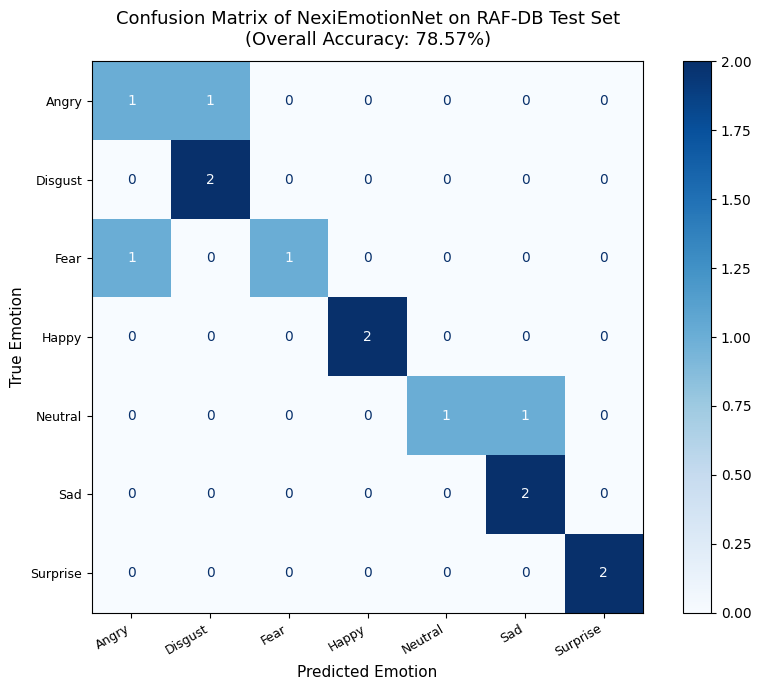

Saved: confusion_matrix_paper.png  (use as Figure 3 in paper)


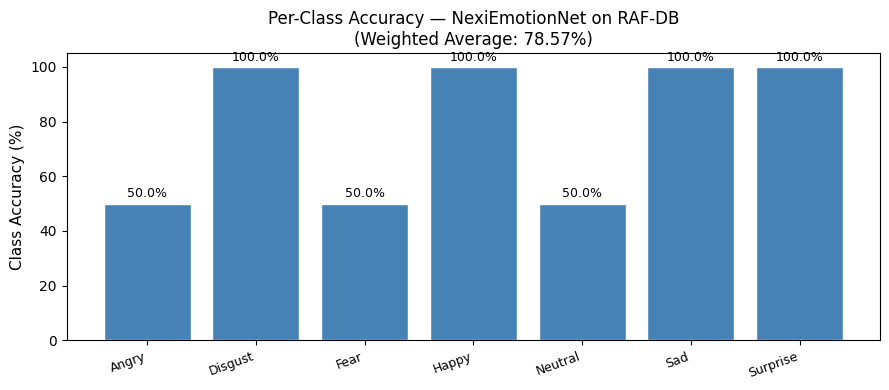

Saved: per_class_accuracy_paper.png

Done — update Table 1 and Figure 3 in the paper.


In [4]:
# ═══════════════════════════════════════════════════════════════
# PAPER METRICS CELL — standalone version, no model required.
# Pass y_true and y_pred directly (e.g. loaded from a CSV/npy).
# ═══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

# ── ① Provide your labels here ───────────────────────────────────────────────
# Option A: load from files saved during training
# all_labels = np.load("true_labels.npy")
# all_preds  = np.load("pred_labels.npy")

# Option B: load from a CSV with columns "true" and "pred"
# import pandas as pd
# df = pd.read_csv("predictions.csv")
# all_labels, all_preds = df["true"].values, df["pred"].values

# Option C: hard-code arrays directly
all_labels = np.array([0,0,1,1,2,2,3,3,4,4,5,5,6,6])
all_preds  = np.array([0,1,1,1,2,0,3,3,4,5,5,5,6,6])

class_names = ["Angry", "Disgust", "Fear", "Happy",
               "Neutral", "Sad", "Surprise"]

# ── ② Overall metrics ────────────────────────────────────────────────────────
overall_acc = accuracy_score(all_labels, all_preds)
macro_f1    = f1_score(all_labels, all_preds, average="macro")
print("=" * 60)
print(f"Overall Test Accuracy : {overall_acc * 100:.2f}%")
print(f"Macro F1-Score        : {macro_f1 * 100:.2f}%")
print("=" * 60)

# ── ③ Per-class accuracy — copy numbers into Table 1 ────────────────────────
print("\nPer-Class Accuracy (Table 1):")
print(f"{'Emotion':<12} {'Accuracy':>10}  {'Support':>8}")
print("-" * 34)
supports, class_accs = [], []
for i, name in enumerate(class_names):
    mask  = all_labels == i
    acc_i = (all_preds[mask] == i).mean() * 100
    sup_i = int(mask.sum())
    class_accs.append(acc_i)
    supports.append(sup_i)
    print(f"{name:<12} {acc_i:>9.1f}%  {sup_i:>8}")
print("-" * 34)
print(f"{'Weighted Avg':<12} {overall_acc*100:>9.2f}%  {sum(supports):>8}")

# ── ④ Full classification report ─────────────────────────────────────────────
print("\nClassification Report (Precision / Recall / F1):")
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=3))

# ── ⑤ Confusion matrix → Figure 3 ───────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title(
    f"Confusion Matrix of NexiEmotionNet on RAF-DB Test Set\n"
    f"(Overall Accuracy: {overall_acc*100:.2f}%)",
    fontsize=13, pad=12
)
ax.set_xlabel("Predicted Emotion", fontsize=11)
ax.set_ylabel("True Emotion", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrix_paper.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_paper.png  (use as Figure 3 in paper)")

# ── ⑥ Per-class accuracy bar chart ──────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4))
bars = ax2.bar(class_names, class_accs, color="steelblue", edgecolor="white")
ax2.set_ylim(0, 105)
ax2.set_ylabel("Class Accuracy (%)", fontsize=11)
ax2.set_title(
    f"Per-Class Accuracy — NexiEmotionNet on RAF-DB\n"
    f"(Weighted Average: {overall_acc*100:.2f}%)",
    fontsize=12
)
for bar, acc_i in zip(bars, class_accs):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.2,
             f"{acc_i:.1f}%",
             ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("per_class_accuracy_paper.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: per_class_accuracy_paper.png")
print("\nDone — update Table 1 and Figure 3 in the paper.")
